In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('tech_layoffs_2026_tracker.csv')

In [3]:
df.head()

,company,layoff_date,jobs_cut,pct_workforce_cut,sector,country,hq_city,ai_cited,reason_stated,company_revenue_2025_bn,...,layoffs_2024,layoffs_2025,verified_source,month,quarter,region,layoff_size_category,stock_reaction,laid_off_vs_headcount_pct,data_as_of
0,Amazon,2026-01-15,16000,2.7,E-Commerce/Cloud,USA,Seattle,False,Reduce bureaucracy and management layers,716.9,...,4000,14000,CNBC / NetworkWorld,January 2026,Q1 2026,North America,Mega (5K+),Positive,1.03,"March 18, 2026"
1,Block,2026-02-28,4000,40.0,Fintech,USA,San Francisco,True,AI tools replace roles enabling smaller teams,22.4,...,0,1000,CNBC / Crunchbase,February 2026,Q1 2026,North America,Large (2K-5K),Positive,40.00,"March 18, 2026"
2,Meta Reality Labs,2026-01-20,1500,10.0,Social Media/VR,USA,Menlo Park,True,Pivot from metaverse to AI research,164.5,...,0,500,InformationWeek / NYT,January 2026,Q1 2026,North America,Medium (500-2K),Positive,1.90,"March 18, 2026"
3,Atlassian,2026-03-14,1600,10.0,Enterprise Software,Australia,Sydney,True,Pivot to AI-first company strategy,5.1,...,0,500,TechRepublic / Metaintro,March 2026,Q1 2026,Asia-Pacific,Medium (500-2K),Positive,10.00,"March 18, 2026"
4,Oracle,2026-02-01,30000,15.0,Enterprise Software,USA,Austin,True,AI data centres replace human ops,52.9,...,6000,10000,IBTimes,February 2026,Q1 2026,North America,Mega (5K+),Positive,15.00,"March 18, 2026"


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   company                        28 non-null     object 
 1   layoff_date                    28 non-null     object 
 2   jobs_cut                       28 non-null     int64  
 3   pct_workforce_cut              28 non-null     float64
 4   sector                         28 non-null     object 
 5   country                        28 non-null     object 
 6   hq_city                        28 non-null     object 
 7   ai_cited                       28 non-null     bool   
 8   reason_stated                  28 non-null     object 
 9   company_revenue_2025_bn        28 non-null     float64
 10  pre_layoff_headcount           28 non-null     int64  
 11  stock_change_day_pct           28 non-null     float64
 12  simultaneous_ai_investment_bn  28 non-null     float

In [6]:
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

In [7]:
print(df.isnull().sum())

company                          0
layoff_date                      0
jobs_cut                         0
pct_workforce_cut                0
sector                           0
country                          0
hq_city                          0
ai_cited                         0
reason_stated                    0
company_revenue_2025_bn          0
pre_layoff_headcount             0
stock_change_day_pct             0
simultaneous_ai_investment_bn    0
roles_most_affected              0
replacement_roles                0
ceo_quote                        0
layoffs_2024                     0
layoffs_2025                     0
verified_source                  0
month                            0
quarter                          0
region                           0
layoff_size_category             0
stock_reaction                   0
laid_off_vs_headcount_pct        0
data_as_of                       0
dtype: int64


In [8]:
df.drop_duplicates(inplace=True)

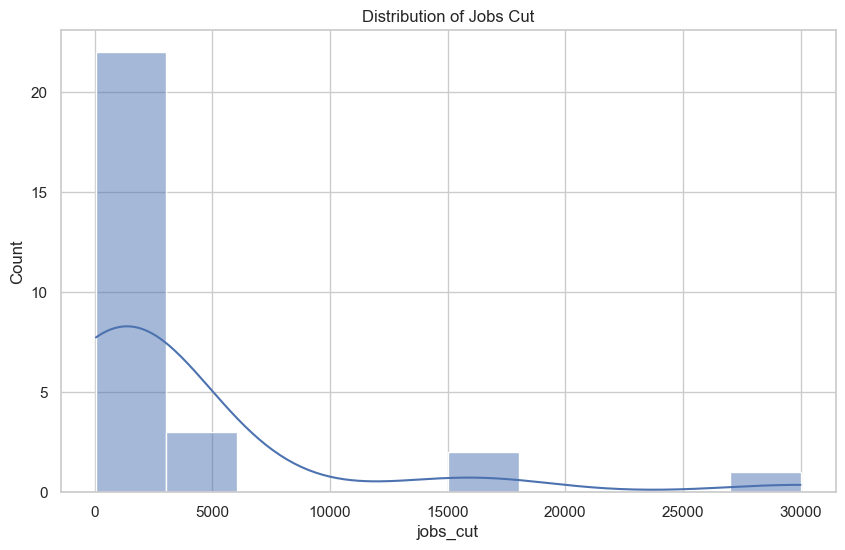

In [9]:
sns.histplot(df['jobs_cut'],bins=10,kde=True)
plt.title("Distribution of Jobs Cut")
plt.show()

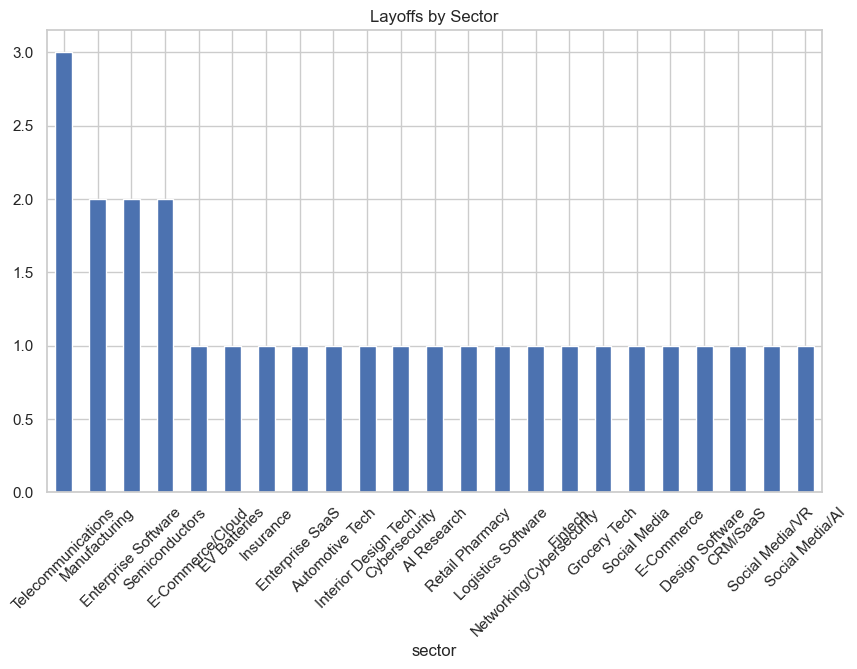

In [10]:
df['sector'].value_counts().plot(kind='bar')
plt.title("Layoffs by Sector")
plt.xticks(rotation=45)
plt.show()

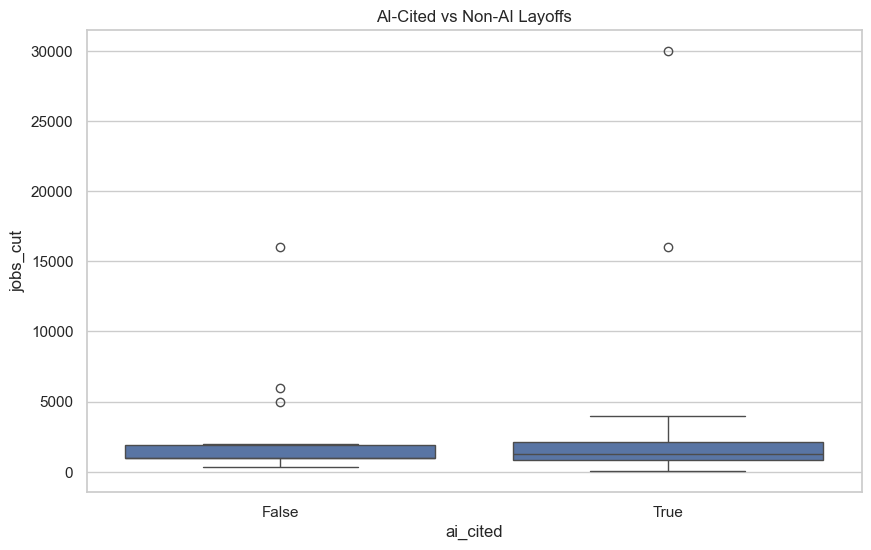

In [11]:
sns.boxplot(x='ai_cited',y='jobs_cut',data=df)
plt.title("AI-Cited vs Non-AI Layoffs")
plt.show()

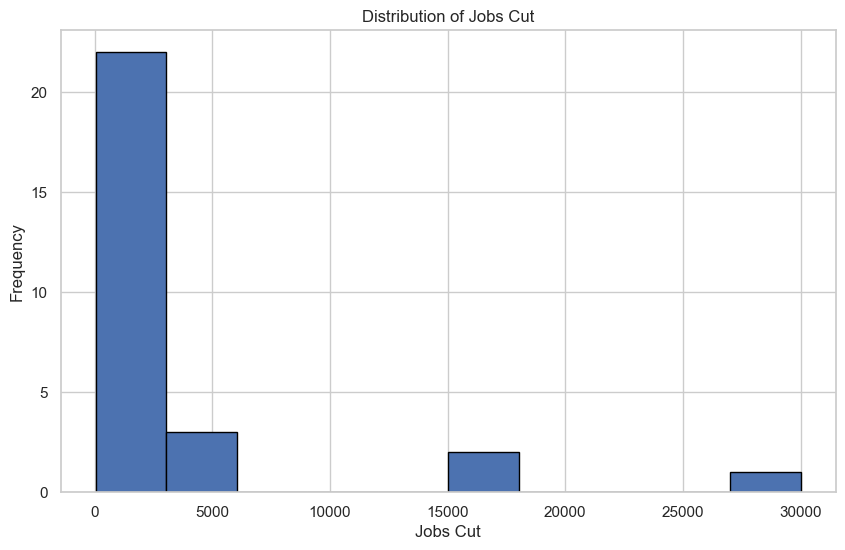

In [13]:
plt.figure()
plt.hist(df['jobs_cut'],bins=10,edgecolor='black')
plt.title("Distribution of Jobs Cut")
plt.xlabel("Jobs Cut")
plt.ylabel("Frequency")
plt.show()

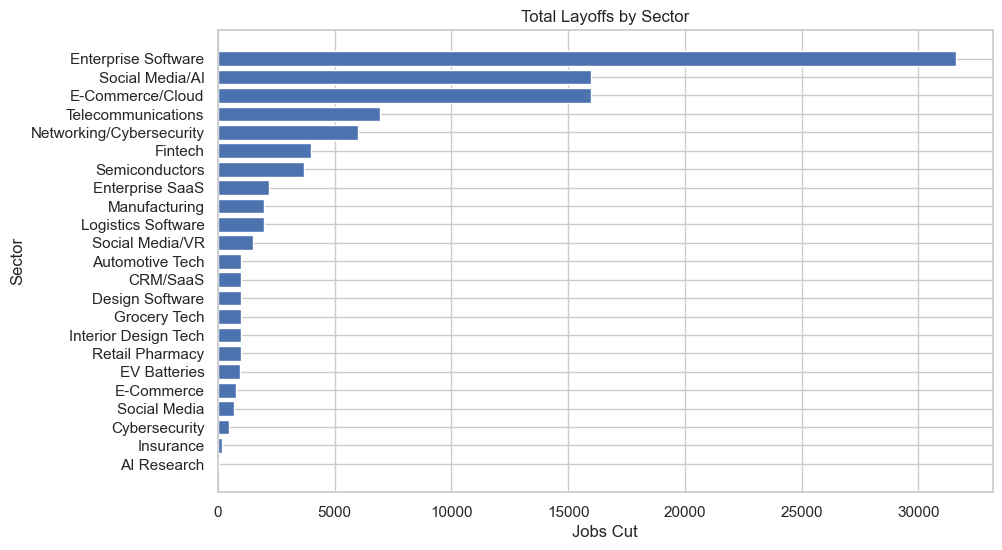

In [16]:
sector_layoffs = df.groupby('sector')['jobs_cut'].sum().sort_values()
plt.figure()
plt.barh(sector_layoffs.index,sector_layoffs.values)
plt.title("Total Layoffs by Sector")
plt.xlabel("Jobs Cut")
plt.ylabel("Sector")
plt.show()

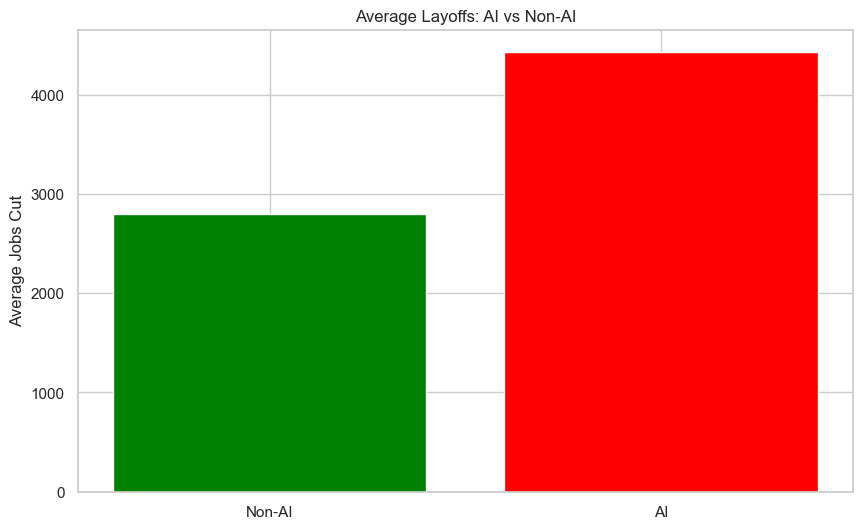

In [17]:
ai_layoffs = df.groupby('ai_cited')['jobs_cut'].mean()
plt.figure()
plt.bar(['Non-AI','AI'],ai_layoffs.values, color=['green','red'])
plt.title("Average Layoffs: AI vs Non-AI")
plt.ylabel("Average Jobs Cut")
plt.show()

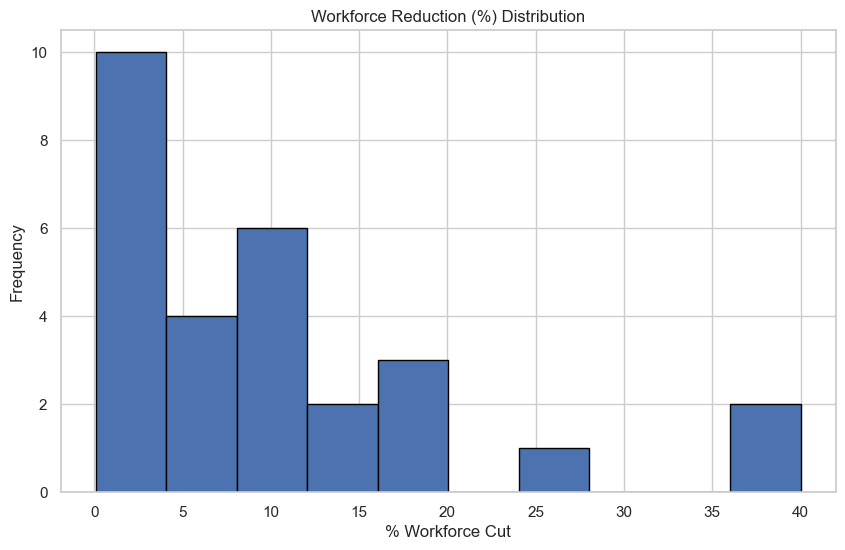

In [18]:
plt.figure()
plt.hist(df['pct_workforce_cut'],bins=10,edgecolor='black')
plt.title("Workforce Reduction (%) Distribution")
plt.xlabel("% Workforce Cut")
plt.ylabel("Frequency")
plt.show()

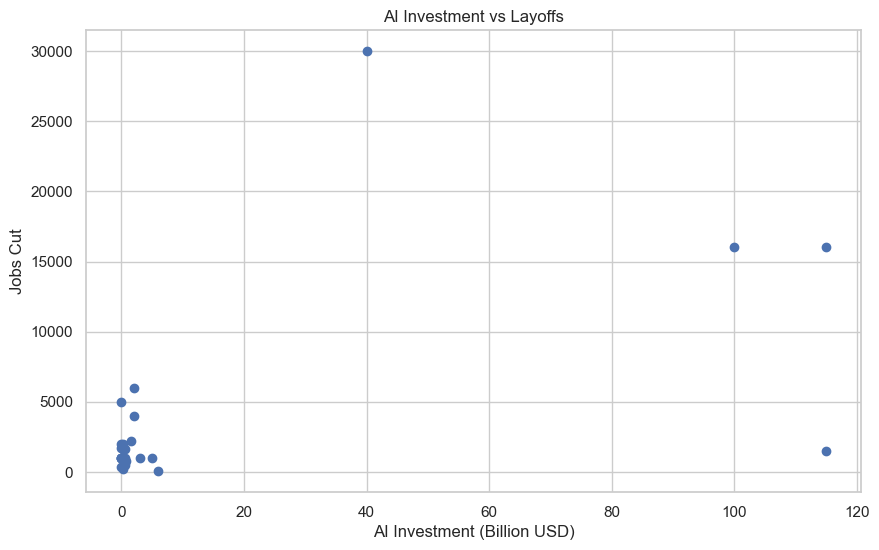

In [19]:
plt.figure()
plt.scatter(df['simultaneous_ai_investment_bn'],df['jobs_cut'])
plt.title("AI Investment vs Layoffs")
plt.xlabel("AI Investment (Billion USD)")
plt.ylabel("Jobs Cut")
plt.show()